# 01 - Load and plot record a14

Goal: verify that we can load one Set-A PhysioNet record, inspect the four abdominal ECG channels, and overlay the reference fetal QRS annotations.

In [12]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
from data_io import load_record
from plotting import plot_record_overview, plot_reference_fqrs


## Load `a14` from PhysioNet

The record is downloaded/read through `wfdb`, so no manual `.dat`, `.hea`, or `.fqrs` download is needed.

In [13]:
record = load_record('a14')

print(f'Record: {record.name}')
print(f'Sampling frequency: {record.fs:.0f} Hz')
print(f'Signal shape: {record.signals.shape}  # samples x channels')
print(f'Duration: {record.time[-1]:.2f} s')
print(f'Channels: {record.channels}')
print(f'Reference fetal QRS annotations: {len(record.fqrs_reference)}')
print(f'First 10 FQRS samples: {record.fqrs_reference[:10]}')


Record: a14
Sampling frequency: 1000 Hz
Signal shape: (60000, 4)  # samples x channels
Duration: 60.00 s
Channels: ['AECG1', 'AECG2', 'AECG3', 'AECG4']
Reference fetal QRS annotations: 123
First 10 FQRS samples: [ 157  608 1056 1516 1976 2435 2897 3359 3824 4283]


## Plot the abdominal ECG channels

This is the raw input signal `S1` before filtering or maternal ECG cancellation.

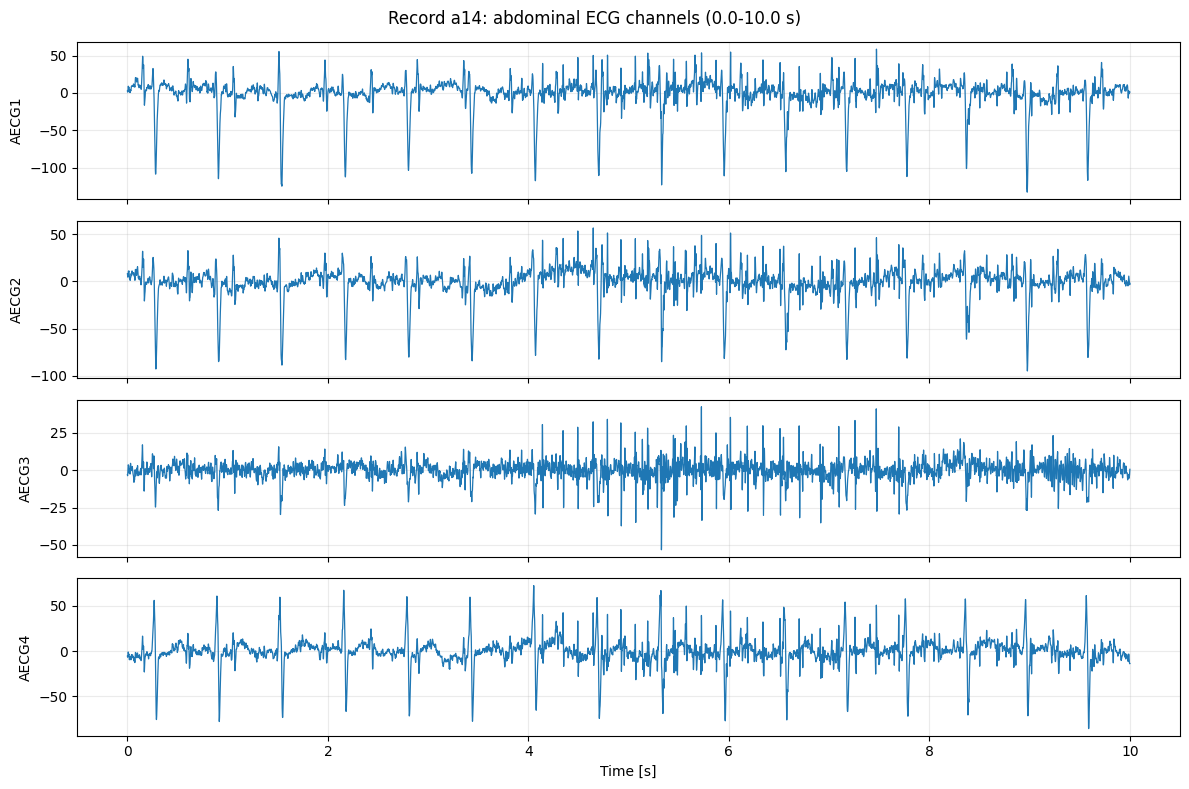

In [14]:
fig, axes = plot_record_overview(
    record,
    seconds=(0, 10),
    save_path=PROJECT_ROOT / 'figures' / 'notebook01' / 'a14_s1_overview_0_10s.png',
)
plt.show()


## Overlay the reference fetal QRS annotations

The red markers are the reference fetal QRS locations from PhysioNet.

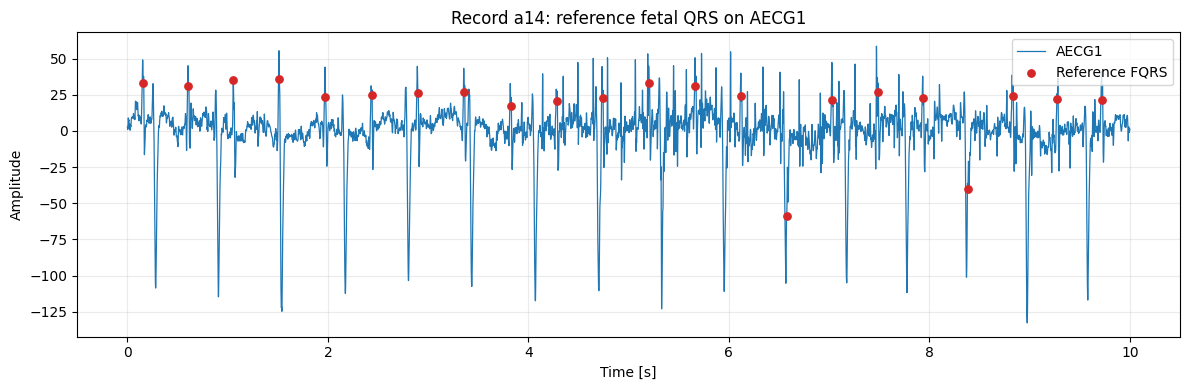

In [24]:
fig, ax = plot_reference_fqrs(
    record,
    channel=0,
    seconds=(0, 10),
    save_path=PROJECT_ROOT / 'figures' / 'notebook01' / 'a14_reference_fqrs_ch1_0_10s.png',
)
plt.show()


## Full-record view

The previous plots use only the first 10 seconds because they are easier to inspect. For documentation, we also save a complete 60-second view of the same record.

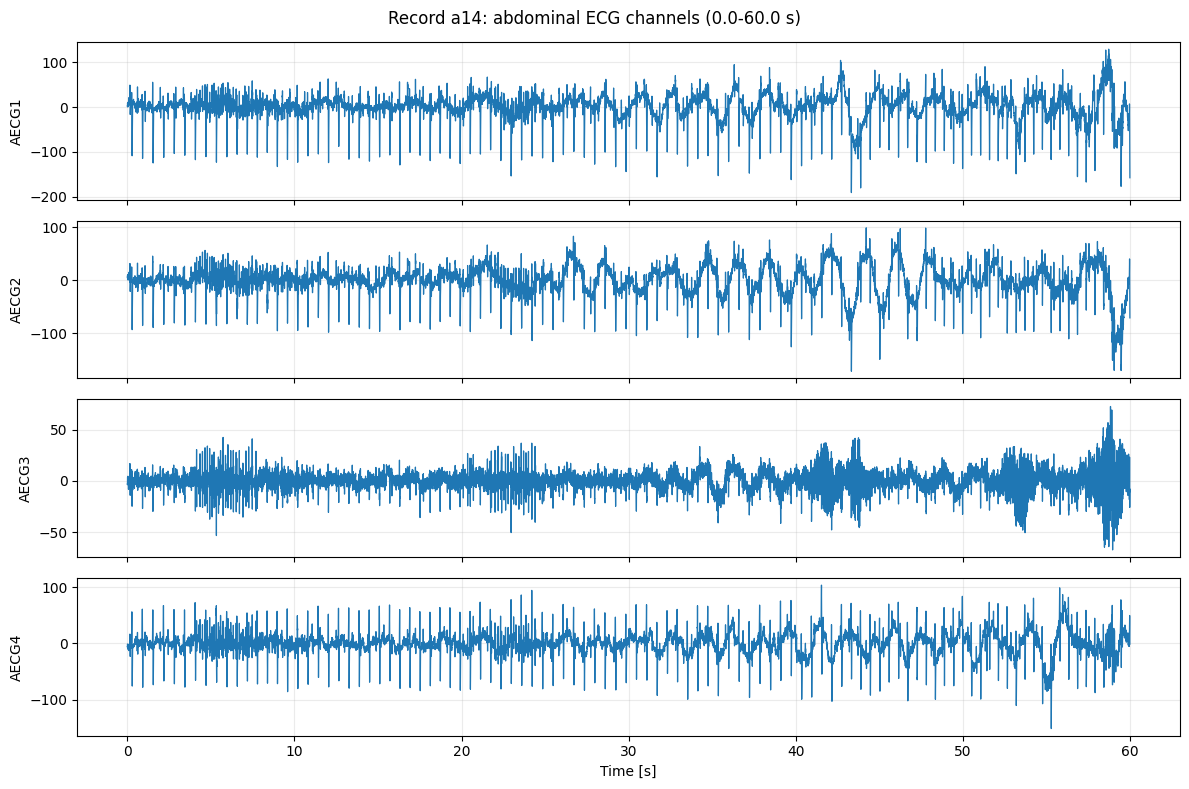

In [16]:
full_window = (0, record.time[-1])

fig, axes = plot_record_overview(
    record,
    seconds=full_window,
    save_path=PROJECT_ROOT / 'figures' / 'notebook01' / 'a14_s1_overview_full.png',
)
plt.show()


## Full raw signal with fetal QRS reference

This plot shows the complete raw signal of channel 1 with all reference fetal QRS annotations. The red markers are not our detection result: they are the PhysioNet reference used later for validation.

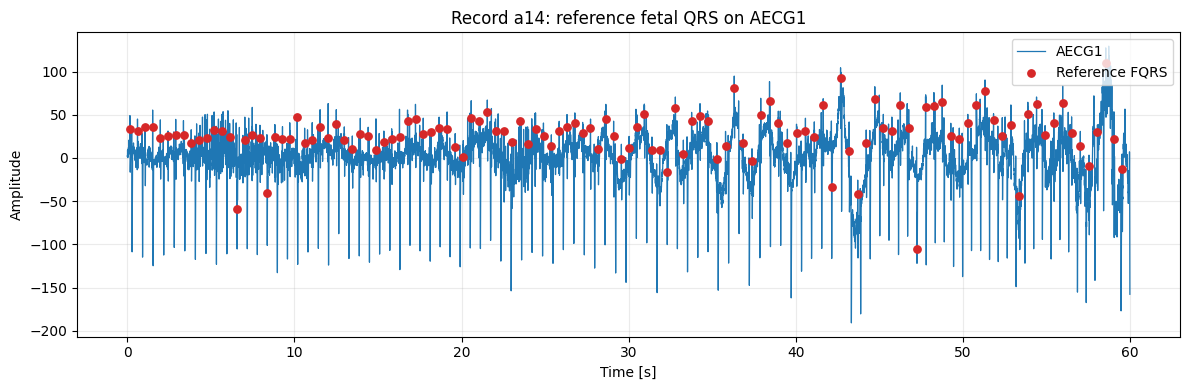

In [17]:
fig, ax = plot_reference_fqrs(
    record,
    channel=0,
    seconds=full_window,
    save_path=PROJECT_ROOT / 'figures' / 'notebook01' / 'a14_reference_fqrs_ch1_full.png',
)
plt.show()


## Notes

Next notebook/script: implement baseline wander removal and power-line interference cancellation.